## Script to read in, modify and plot aerosol emissions data for a CAM run
### - Read in data
### - Select region on globe modify the values of the data
### - Write to separate file.

In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import cartopy.crs as ccrs
from cartopy.feature import LAND


In [59]:
## Biomass burning files.

#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_bc_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_DMS_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_pom_a4_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_SO2_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_so4_a1_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'emiss_bb' ; emis_file =  'emissions-cmip6_SOAGx1.5_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'num_so4_a1_bb' ; emis_file = 'emissions-cmip6_num_so4_a1_bb_surface_2000climo_0.9x1.25_c20170322'
#var_name = 'num_bc_a4_bb' ; emis_file = 'emissions-cmip6_num_bc_a4_bb_surface_2000climo_0.9x1.25_c20170322'
var_name = 'num_pom_a4_bb' ; emis_file = 'emissions-cmip6_num_pom_a4_bb_surface_2000climo_0.9x1.25_c20170509'



#var_name = 'emiss_anthro' ; emis_file =  'emissions-cmip6_bc_a4_anthro_surface_2000climo_0.9x1.25_c20170608'

#scale_factor = 0.0 ; fscale_factor = 'x0.0'
#scale_factor = 0.5 ; fscale_factor = 'x0.5'
#scale_factor = 2.0 ; fscale_factor = 'x2.0'
scale_factor = 10.0 ; fscale_factor = 'x10.0'

#region = 'amazon'
#region = 'na-boreal'
region  = 'global'


emis_type = 'CMIP6_emissions_2000climo'
#emis_type = 'CMIP6_emissions_1750_2015'


emis_dir_out = '/glade/work/rneale/aero_howard/datasets/'
emis_dir_in = '/glade/p/cesmdata/cseg/inputdata/atm/cam/chem/emis/'

In [60]:
emis_dir = emis_dir_in+emis_type+'/'


ds_in = xr.open_dataset(emis_dir+emis_file+'.nc')
da_in = ds_in[var_name]

In [61]:

# Masking domains
if region == 'amazon' : mmin_lon = 290. ;   mmax_lon = 315. ;   mmin_lat = -20.   ; mmax_lat = -5. ; pmin_lon = 270 ;   pmax_lon = 320. ;   pmin_lat = -30.  ; pmax_lat = 15.
if region == 'na-boreal' :   mmin_lon = 190. ;   mmax_lon = 310. ;   mmin_lat = 50.   ; mmax_lat = 70. ; pmin_lon = 181. ;   pmax_lon = 320. ;   pmin_lat = 40.  ; pmax_lat = 80.

if region == 'global' :   mmin_lon = 0. ;   mmax_lon = 360. ;   mmin_lat = -90.   ; mmax_lat = 90. ; pmin_lon = 0. ;   pmax_lon = 360. ;   pmin_lat = -90.  ; pmax_lat = 90.



# Sub-domain plot

#mask_lon = (da_in.lon >= pmin_lon) & (da_in.lon <= pmax_lon)
#mask_lat = (da_in.lat >= pmin_lat) & (da_in.lat <= pmax_lat)

#da_in = da_in.where(mask_lon & mask_lat, drop=True)

# Sub-domain plot maskf
display(ds_in)

da_mod = da_in.copy()
print(da_in.max())

if region != 'global':

    mask_lon = (da_in.lon >= mmin_lon) & (da_in.lon <= mmax_lon)
    mask_lat = (da_in.lat >= mmin_lat) & (da_in.lat <= mmax_lat)

    
#da_mod = da_mod.where(mask_lon & mask_lat, 1000) 


#da_mod.loc[{"lat": mask_lat, "lon": mask_lon}] = 10e16
    da_mod.loc[{"lat": mask_lat, "lon": mask_lon}] = scale_factor*da_mod.loc[{"lat": mask_lat, "lon": mask_lon}]

else:

    da_mod.values = scale_factor*da_mod.values


#da_mod = vscale*da_mod
#ds_in[var_name].data = scale_factor*da_mod.data


ds_in[var_name] = da_mod
display(ds_in)
print(da_mod.max())



<xarray.Dataset> Size: 3MB
Dimensions:        (lon: 288, lat: 192, time: 12)
Coordinates:
  * lon            (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lat            (lat) float32 768B -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * time           (time) datetime64[ns] 96B 2000-01-16T08:48:44.999999488 .....
Data variables:
    date           (time) int32 48B ...
    num_pom_a4_bb  (time, lat, lon) float32 3MB ...
Attributes: (12/13)
    data_title:                Emissions of num_pom_a4_bb for CESM-MAM4 CMIP6
    molecular_weight:          1.0
    data_creator:              Jean-Francois Lamarque (lamar@ucar.edu) and Lo...
    data_summary:              Emissions of number of particles for correspon...
    cesm_contact:              Louisa Emmons or Simone Tilmes
    creation_date:             20170509
    ...                        ...
    history:                   Thu Dec 21 11:44:07 2017: ncatted -a average,g...
    data_script:               /glade/u/home/emmons/CMIP6/emissions/make_emis...
    data_source_url:           http://www.globalchange.umd.edu/ceds/ceds-cmip...
    data_reference:            Number calculations described in X.Liu et al.,...
    nco_openmp_thread_number:  1
    average:                   Average period between 1995 and 2005

<xarray.DataArray 'num_pom_a4_bb' ()> Size: 8B
array(2.18643867e+32)


<xarray.Dataset> Size: 3MB
Dimensions:        (lon: 288, lat: 192, time: 12)
Coordinates:
  * lon            (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lat            (lat) float32 768B -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * time           (time) datetime64[ns] 96B 2000-01-16T08:48:44.999999488 .....
Data variables:
    date           (time) int32 48B ...
    num_pom_a4_bb  (time, lat, lon) float32 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes: (12/13)
    data_title:                Emissions of num_pom_a4_bb for CESM-MAM4 CMIP6
    molecular_weight:          1.0
    data_creator:              Jean-Francois Lamarque (lamar@ucar.edu) and Lo...
    data_summary:              Emissions of number of particles for correspon...
    cesm_contact:              Louisa Emmons or Simone Tilmes
    creation_date:             20170509
    ...                        ...
    history:                   Thu Dec 21 11:44:07 2017: ncatted -a average,g...
    data_script:               /glade/u/home/emmons/CMIP6/emissions/make_emis...
    data_source_url:           http://www.globalchange.umd.edu/ceds/ceds-cmip...
    data_reference:            Number calculations described in X.Liu et al.,...
    nco_openmp_thread_number:  1
    average:                   Average period between 1995 and 2005

<xarray.DataArray 'num_pom_a4_bb' ()> Size: 8B
array(2.18643871e+33)


360.0 180.0 [0.0, -90.0]


NameError: name 'cs1' is not defined

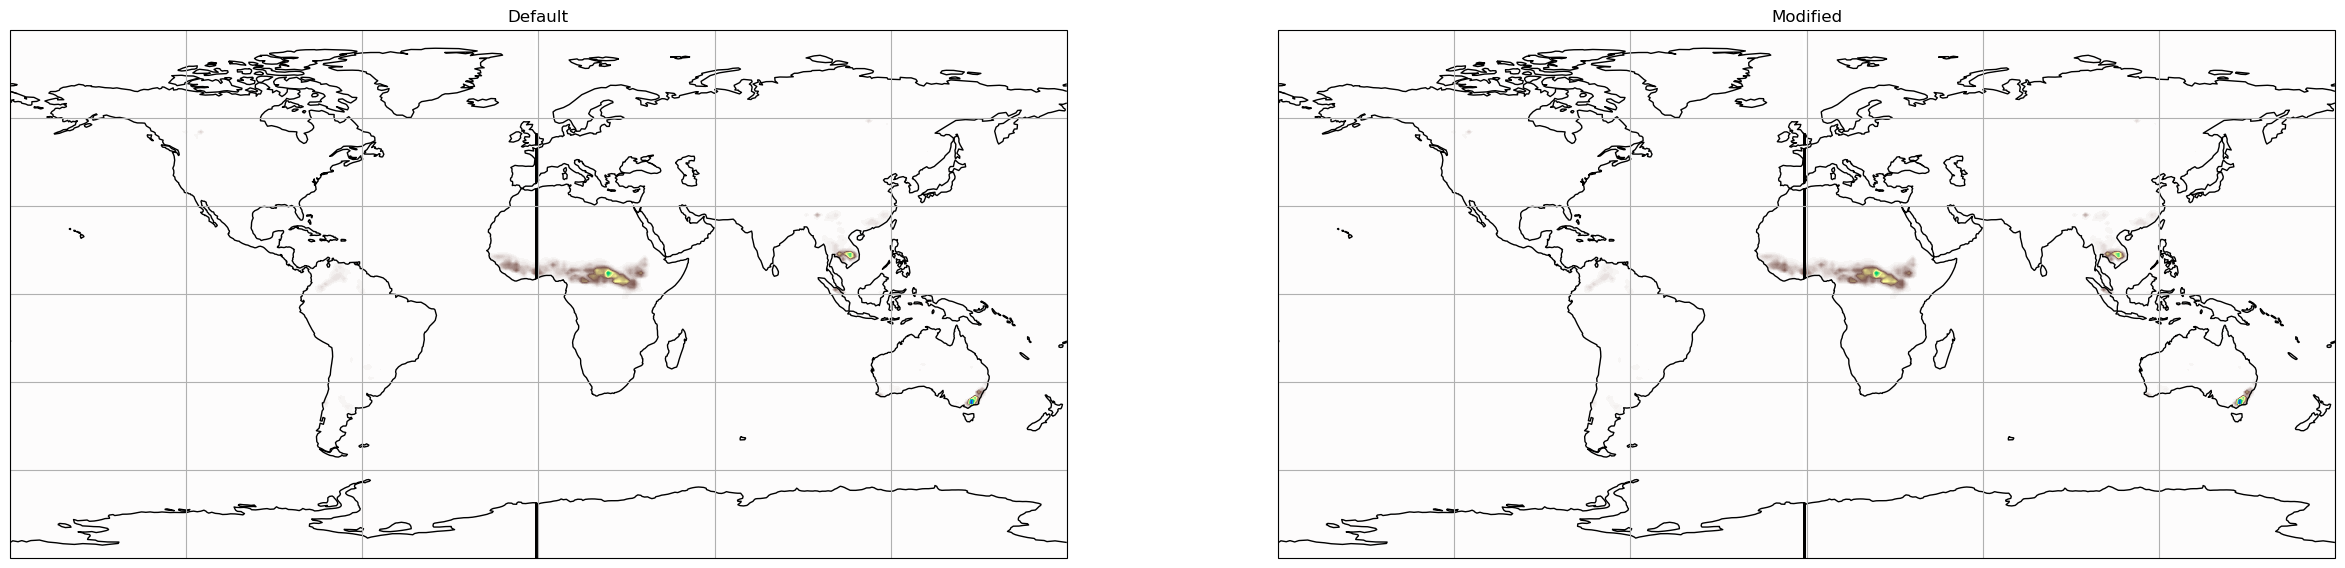

In [62]:
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(30,15))

cmap = 'ocean_r'
cmap = 'terrain_r'

imonth = 0

axs[0].contourf(da_in.lon,da_in.lat,da_in[imonth,:,:],levels=100,cmap=cmap)
axs[1].contourf(da_mod.lon,da_mod.lat,10.*da_mod[imonth,:,:],levels=100,cmap=cmap)

axs[0].set_global() if region == 'global' else  axs[0].set_extent([pmin_lon, pmax_lon, pmin_lat, pmax_lat])
axs[1].set_global() if region == 'global' else  axs[1].set_extent([pmin_lon, pmax_lon, pmin_lat, pmax_lat])



# Calculate box dims
bxy = [mmin_lon,mmin_lat]
bx = (mmax_lon-mmin_lon)
by = (mmax_lat-mmin_lat)

print(bx,by,bxy)

axs[0].add_patch(mpatches.Rectangle(xy=bxy, width=bx, height=by,
                                    facecolor='k',
                                    alpha=0.2,
                                    transform=ccrs.PlateCarree())
                 )

axs[1].add_patch(mpatches.Rectangle(xy=bxy, width=bx, height=by,
                                    facecolor='k',
                                    alpha=0.2,
                                    transform=ccrs.PlateCarree())
                 )

axs[0].gridlines()
axs[1].gridlines()
axs[0].add_feature(LAND,color='k')
axs[1].add_feature(LAND,color='k')

axs[0].set_title('Default')
axs[1].set_title('Modified')
axs[0].coastlines()
axs[1].coastlines()


cbar = fig.colorbar(cs1, ax=axs, location='right', shrink=0.6, pad=0.05)

print(region+'_'+emis_file+'.png')

plt.savefig(region+'_'+emis_file+'.png', dpi=120, bbox_inches='tight') 
plt.show()

In [63]:
display(ds_in)


## OUTPUT NETCDF ##

print(emis_file+'_'+region+fscale_factor+'.nc')
ds_in.to_netcdf(path=emis_dir_out+emis_file+'_'+region+"_"+fscale_factor+'.nc')

<xarray.Dataset> Size: 3MB
Dimensions:        (lon: 288, lat: 192, time: 12)
Coordinates:
  * lon            (lon) float32 1kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * lat            (lat) float32 768B -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * time           (time) datetime64[ns] 96B 2000-01-16T08:48:44.999999488 .....
Data variables:
    date           (time) int32 48B ...
    num_pom_a4_bb  (time, lat, lon) float32 3MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes: (12/13)
    data_title:                Emissions of num_pom_a4_bb for CESM-MAM4 CMIP6
    molecular_weight:          1.0
    data_creator:              Jean-Francois Lamarque (lamar@ucar.edu) and Lo...
    data_summary:              Emissions of number of particles for correspon...
    cesm_contact:              Louisa Emmons or Simone Tilmes
    creation_date:             20170509
    ...                        ...
    history:                   Thu Dec 21 11:44:07 2017: ncatted -a average,g...
    data_script:               /glade/u/home/emmons/CMIP6/emissions/make_emis...
    data_source_url:           http://www.globalchange.umd.edu/ceds/ceds-cmip...
    data_reference:            Number calculations described in X.Liu et al.,...
    nco_openmp_thread_number:  1
    average:                   Average period between 1995 and 2005

emissions-cmip6_num_pom_a4_bb_surface_2000climo_0.9x1.25_c20170509_globalx10.0.nc
